# Imports

In [ ]:
import base64

from src.utils import openai_client

# 웹 상의 이미지에 대한 설명 텍스트 생성

*   https://picsum.photos 사이트에서 랜덤하게 보여주는 이미지 사용
*   https://picsum.photos/width/height 형식으로 요청을 보내면 원하는 크기의 랜덤한 이미지를 볼 수 있음.
*   https://picsum/photos/size 형식으로 요청을 보내면 정사각형 모양의 랜덤한 이미지를 볼 수 있음.

In [ ]:
# GPT에게 보낼 사용자 프롬프트
messages = [
    {
        'role': 'user',
        'content': [
            {
                'type': 'input_text',
                'text': '이 이미지에 대해서 설명해줘.',
            },
            {
                'type': 'input_image',
                'image_url': 'https://fastly.picsum.photos/id/5/1920/1080.jpg?hmac=dY3vh1Bc6PFJKF18w5_dQoGRU3_IV4LFZoS2oN1zm1Q',
            },
        ],
    },
]

In [ ]:
response = openai_client.responses.create(
    model='gpt-6-luna',
    input=messages
)

In [ ]:
print(response.to_json())

In [ ]:
print(response.output_text)

# 로컬 이미지 파일의 설명 생성

*   이미지와 같은 바이너리 데이터는 ASCII 문자 형식으로 변환해서 GPT에게 요청을 보냄.
*   base64 라이브러리: 이진 데이터(binary data)를 ASCII 문자로 변환(encoding).
    *   전송/저장 호환성 유지
    *   데이터 손상 방지
    *   프로토콜 호환성
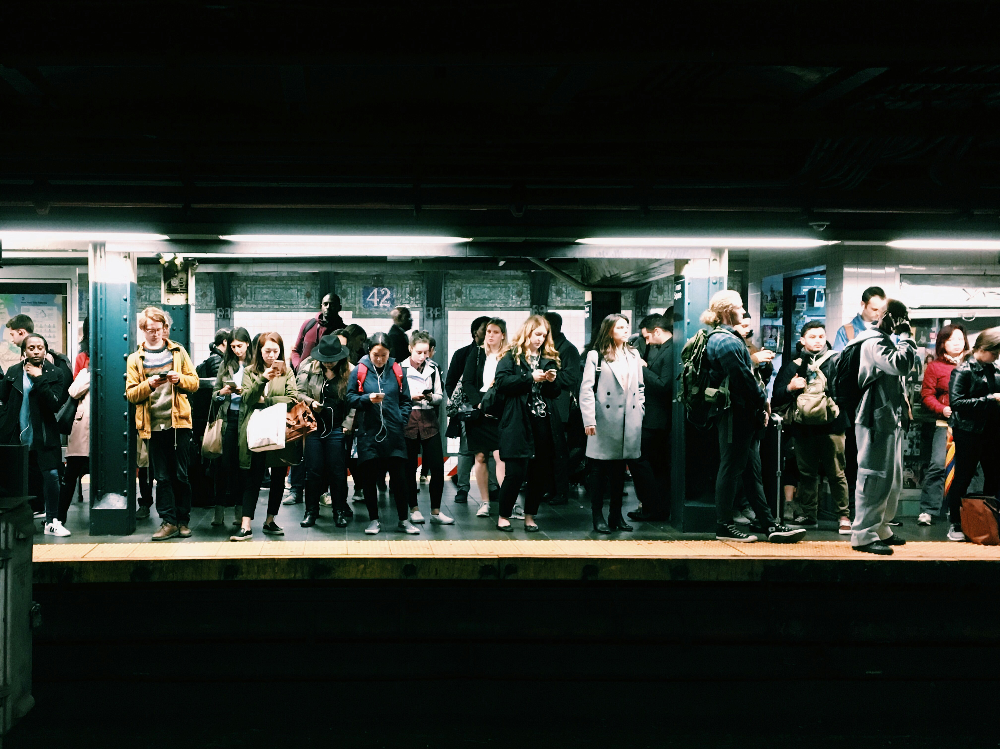

In [ ]:
def base64_encode_image(image_file):
    # 이미지 파일을 이진 데이터 읽기 모드로 오픈.
    with open(image_file, mode='rb') as f:
        data = f.read()  # 파일 내용 전체를 읽음.

    # b64encode(): binary data를 ASCII 형식의 문자열들로 변환
    # decode(): ASCII 타입 문자열을 UTF-8 형식의 문자열로 변환
    return base64.b64encode(data).decode(encoding='utf-8')

In [ ]:
# 이미지 파일이 저장된 경로
image_1 = 'C:/workspaces/lab_llm/data/images/image_1.jpg'
image_2 = 'C:/workspaces/lab_llm/data/images/image_2.jpg'

In [ ]:
base64_encode_image(image_1)[:100]

In [ ]:
# 로컬 이미지 데이터를 GPT로 보내서 이미지 설명을 요청하기 위한 프롬프트 작성.
messages = [
    {
        'role': 'user',
        'content': [
            {
                'type': 'input_text',
                'text': '이 이미지에 대해서 자세히 설명해줘.',
            },
            {
                'type': 'input_image',
                'image_url': f'data:image/jpg;base64,{base64_encode_image(image_2)}',
            },
        ],
    },
]

In [ ]:
response = openai_client.responses.create(
    model='gpt-6-luna',
    input=messages
)

In [ ]:
print(response.output_text)

# 2개 이미지를 비교/설명을 요청하는 프롬프트를 작성하고, 결과를 출력

In [ ]:
# 이미지 파일들이 저장된 경로
cafe_1 = 'C:/workspaces/lab_llm/data/images/cafe_1.jpg'
cafe_2 = 'C:/workspaces/lab_llm/data/images/cafe_2.jpg'

In [ ]:
# 이미지들을 base64 모듈을 사용해서 ASCII 형식으로 인코딩.
cafe_encoded_1 = base64_encode_image(cafe_1)
cafe_encoded_2 = base64_encode_image(cafe_2)

In [ ]:
cafe_encoded_1[:100]

In [ ]:
cafe_encoded_2[:100]

In [ ]:
# 프롬프트 작성
messages = [
    {
        'role': 'user',
        'content': [
            {
                'type': 'input_text',
                'text': '두 이미지의 차이점을 비교 설명해줘.',
            },
            {
                'type': 'input_image',
                'image_url': f'data:image/jpg;base64,{cafe_encoded_1}',
            },
            {
                'type': 'input_image',
                'image_url': f'data:image/jpg;base64,{cafe_encoded_2}',
            },
        ],
    },
]

In [ ]:
response = openai_client.responses.create(
    model='gpt-6-luna',
    input=messages
)

In [ ]:
print(response.output_text)